# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 3 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~2에서는 VAE와 DCGAN을 MNIST로 직접 구현하고 학습합니다. Part 3에서는 DDPM의 핵심 구조와 손실함수를 구현한 뒤 사전학습 모델로 이미지를 생성합니다. Part 4에서는 Hugging Face `diffusers` 라이브러리로 사전학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [3]:
# torch version update로 인한 재설치
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


In [4]:
# matplotlib 실행도중에 충돌하는 문제 해결
import os

if os.name == "nt":
    # MKL은 단일 스레드. 병렬 연산이 필요하면 패키지 환경을 정리한다.
    os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


### **데이터셋 준비 (MNIST dataset)**

In [5]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 374kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.60MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [6]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

encode는 입력을 fc1과 ReLU에 통과시킨 특징 h1에서 평균 mu와 로그 분산 logvar를 구한다. self.fc21(h1)과 self.fc22(h1)은 서로 다른 선형 계층이므로 두 값을 각각 학습하며, 출력 크기는 모두 (배치 크기, 잠재 차원)이다.

reparameterize는 표준편차를 exp(0.5 × logvar)로 구하고, 같은 크기의 표준 정규 잡음 eps를 뽑아 z = mu + eps × std를 반환한다. 무작위성은 eps에 두고 mu와 std에는 미분 가능한 연산을 적용하므로 복원 손실의 기울기가 encoder까지 전달된다.


### **VAE loss (음의 ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [7]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

elbo_loss는 음의 ELBO를 최소화하도록 복원 오차와 KL divergence를 더한다. 먼저 x를 (B, 784)로 펼친 뒤 recon_x와 x의 binary cross entropy를 구한다. reduction='sum'으로 배치와 픽셀 전체를 합하고 B로 나누므로, BCE는 이미지 한 장당 픽셀 손실의 합을 배치 평균한 값이다.

KLD는 대각 가우시안 q(z|x)와 표준 정규분포 p(z) 사이의 KL divergence다. -0.5 × sum(1 + logvar - mu² - exp(logvar))를 B로 나누고 BCE와 더한다. 여기서 BCE는 입력 복원을, KLD는 잠재 분포의 정규화를 담당한다.

아래 학습 코드에서는 이미 배치 평균을 낸 loss를 더한 뒤 데이터 수로 다시 나눈다. 출력된 Train Loss 1.3167 → 0.8223, Val Loss 1.0282 → 0.8285에서 감소 추세는 확인되지만, 이 수치를 이미지 한 장당 평균 손실로 해석하면 안 된다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.

복원 손실만 줄이면 encoder가 학습 데이터를 서로 떨어진 잠재 영역에 배치해도 제약이 적다. 그러면 학습 때 사용한 잠재값에서는 잘 복원하더라도, 생성할 때 표준 정규분포에서 뽑은 z는 decoder가 충분히 학습하지 못한 영역에 놓일 수 있다.

KL divergence는 q(z|x)가 사전분포 N(0, I)에서 지나치게 벗어나지 않도록 제한한다. 복원에 필요한 정보를 남기면서 잠재 공간을 규칙적으로 구성해, 사전분포에서 샘플링한 z로도 이미지를 생성하도록 돕는다. 다만 KL 제약이 지나치면 입력 정보가 사라지는 posterior collapse가 생길 수 있으므로 복원 항과의 균형이 중요하다.


In [8]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3167 | Val Loss: 1.0282
Epoch [2/15] Train Loss: 0.9661 | Val Loss: 0.9302
Epoch [3/15] Train Loss: 0.9075 | Val Loss: 0.8933
Epoch [4/15] Train Loss: 0.8811 | Val Loss: 0.8748
Epoch [5/15] Train Loss: 0.8658 | Val Loss: 0.8639
Epoch [6/15] Train Loss: 0.8555 | Val Loss: 0.8559
Epoch [7/15] Train Loss: 0.8479 | Val Loss: 0.8495
Epoch [8/15] Train Loss: 0.8423 | Val Loss: 0.8452
Epoch [9/15] Train Loss: 0.8378 | Val Loss: 0.8424
Epoch [10/15] Train Loss: 0.8337 | Val Loss: 0.8372
Epoch [11/15] Train Loss: 0.8311 | Val Loss: 0.8350
Epoch [12/15] Train Loss: 0.8283 | Val Loss: 0.8337
Epoch [13/15] Train Loss: 0.8259 | Val Loss: 0.8310
Epoch [14/15] Train Loss: 0.8240 | Val Loss: 0.8320
Epoch [15/15] Train Loss: 0.8223 | Val Loss: 0.8285


**VAE sampling 시각화**

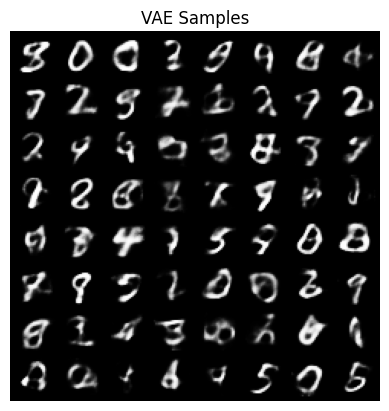

In [9]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 합성곱 가중치는 평균 0, 표준편차 0.02인 정규분포로 초기화
  - BatchNorm 가중치는 평균 1, 표준편차 0.02인 정규분포로, 편향은 0으로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 중간 특징값을 정규화하여 학습 안정성을 높이는 데 도움을 줌
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [11]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [12]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

Generator.forward는 (B, 20, 1, 1) 크기의 잡음 z를 (B, 1, 28, 28) 이미지로 바꾼다. 첫 빈칸에는 z를 넣고, 마지막 빈칸에는 self.tconv4(x)를 넣는다.

전치 합성곱이 공간 크기를 1 → 7 → 14 → 28로 늘리고, 마지막 계층은 28 × 28을 유지하면서 채널을 1개로 줄인다. 중간에는 BatchNorm과 ReLU를 적용하고 마지막에는 tanh를 적용해 픽셀 범위를 학습 데이터와 같은 [-1, 1]로 맞춘다.


In [13]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

Discriminator.forward는 입력 이미지가 실제 데이터인지 판별한다. 빈칸의 self.bn3(self.conv3(x))는 세 번째 합성곱 출력에 BatchNorm을 적용하며, 뒤의 LeakyReLU는 음수 입력에서도 작은 기울기를 유지한다.

공간 크기는 28 → 14 → 7 → 3 → 1로 줄어든다. 마지막 sigmoid 출력은 이미지별 실제 데이터 확률이고, view와 squeeze로 (B, 1, 1, 1)을 (B,)로 바꿔 real 또는 fake 정답 벡터와 크기를 맞춘다.


In [14]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [15]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.7844 | Loss G: 1.7029
Epoch [2/15] Loss D: 0.9015 | Loss G: 1.4473
Epoch [3/15] Loss D: 0.9851 | Loss G: 1.3505
Epoch [4/15] Loss D: 0.9836 | Loss G: 1.3534
Epoch [5/15] Loss D: 1.0032 | Loss G: 1.3432
Epoch [6/15] Loss D: 0.9738 | Loss G: 1.4089
Epoch [7/15] Loss D: 0.9888 | Loss G: 1.3811
Epoch [8/15] Loss D: 0.9613 | Loss G: 1.4485
Epoch [9/15] Loss D: 0.9695 | Loss G: 1.4456
Epoch [10/15] Loss D: 0.9435 | Loss G: 1.4757
Epoch [11/15] Loss D: 0.9396 | Loss G: 1.5010
Epoch [12/15] Loss D: 0.9454 | Loss G: 1.5014
Epoch [13/15] Loss D: 0.9348 | Loss G: 1.5326
Epoch [14/15] Loss D: 0.9000 | Loss G: 1.5735
Epoch [15/15] Loss D: 0.8981 | Loss G: 1.5960


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

Generator는 생성한 fake_img를 Discriminator가 실제 이미지로 판단하도록 학습한다. 따라서 criterion(D(fake_img), real)처럼 목표값을 1인 real로 둔다. 이 손실은 -log D(G(z)) 형태의 non-saturating generator loss에 해당한다.

Discriminator를 학습할 때는 fake_img.detach()로 Generator까지 기울기가 전달되지 않게 한다. Generator를 학습할 때는 detach를 쓰지 않아 D를 거쳐 G까지 기울기를 전달하고, optG.step()으로 G의 파라미터를 갱신한다.

**DCGAN Sampling 시각화**

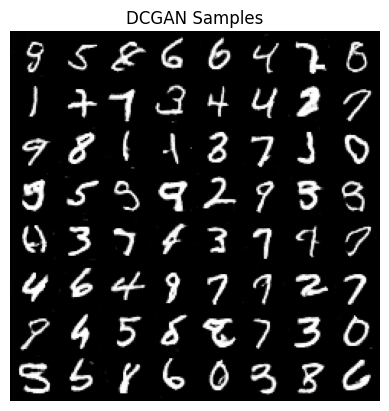

In [16]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

저장된 64장씩의 샘플을 보면 VAE는 획 주변이 번지고 일부 숫자의 경계가 흐릿하다. DCGAN은 대체로 획과 배경의 경계가 더 뚜렷하다.

이 실습의 VAE는 픽셀별 BCE 복원 손실과 KL 제약을 함께 최소화한다. 잠재 표현만으로 획의 위치나 굵기를 정확히 구별하기 어려우면 decoder가 여러 가능한 픽셀값을 평균적인 확률로 표현하므로 경계가 흐릿해질 수 있다.

DCGAN은 특정 원본 이미지와 픽셀 단위로 일치시키기보다 Discriminator가 실제 이미지로 받아들이는 출력을 만들도록 학습한다. 판별자가 획의 경계나 질감을 구별하면 Generator도 이런 특징을 선명하게 만드는 방향으로 학습한다. 다만 선명한 이미지 몇 장이 분포 전체를 잘 학습했다는 뜻은 아니며, 같은 숫자만 반복하는 mode collapse가 함께 나타날 수 있다. 이번 DCGAN 출력에는 여러 숫자와 필체가 보이며, 이 그림만으로 mode collapse가 발생했다고 판단할 수는 없다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

Discriminator가 너무 빨리 강해지면 생성 이미지를 거의 모두 가짜로 구분한다. 원래의 minimax generator loss에서는 이때 기울기가 작아져 Generator 학습이 느려질 수 있다. 이 코드의 -log D(G(z)) 손실은 이런 포화를 완화하지만, 두 모델의 학습 불균형을 항상 해결하지는 않는다.

반대로 Discriminator가 충분히 학습하지 못하면 Generator가 이미지의 부족한 점을 알려주는 유용한 신호를 얻기 어렵다. 일부 패턴만으로 판별자를 속이는 상황이 지속되면 다양한 z를 넣어도 비슷한 숫자만 생성하는 mode collapse가 생길 수 있다. 이를 줄이려면 학습률과 갱신 횟수를 조절하고, 손실값뿐 아니라 생성 이미지의 다양성도 확인해야 한다.

## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 구현합니다. 직접 만든 `SimpleUNet`은 객체만 생성하며, 이를 학습하는 코드는 포함하지 않습니다. 아래 숫자 이미지는 별도로 불러온 Hugging Face의 사전학습 MNIST DDPM 모델이 생성한 결과입니다.


In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [18]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

forward_diffusion은 여러 번의 노이즈 주입을 반복하는 대신, 누적 계수로 원하는 timestep의 x_t를 한 번에 계산한다. 빈칸에는 각각 sqrt_ac와 sqrt_omac를 넣는다.

식은 $x_t=\sqrt{\bar{\alpha}_t}x_0+\sqrt{1-\bar{\alpha}_t}\epsilon$이다. noise는 x0와 같은 크기의 표준 정규 잡음이며, t로 조회한 계수를 (B, 1, 1, 1)로 바꿔 채널과 공간 축에 broadcast한다. 반환한 noise는 노이즈 예측 모델을 학습할 때 정답으로 사용한다.

이 코드는 t를 0부터 세므로 t=0에도 첫 번째 beta에 해당하는 작은 잡음이 들어간다. 저장된 그림에서는 t=0과 100에서 숫자 2의 형태가 보이고, 300 이후에는 획이 점점 구별하기 어려워진다. 각 그림은 호출할 때마다 새 잡음을 뽑은 결과라서 하나의 잡음 주입 과정을 연속으로 기록한 것은 아니다.


**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

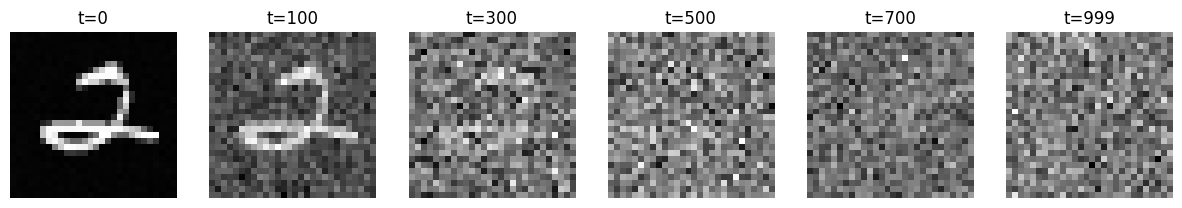

In [19]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [20]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

같은 이미지처럼 보여도 timestep에 따라 섞인 노이즈의 양이 다르므로 U-Net에는 t 정보가 필요하다. time_mlp가 t를 벡터로 바꾸고, time_proj가 bottleneck과 같은 256차원으로 변환한다.

unsqueeze를 두 번 적용한 t_proj의 크기는 (B, 256, 1, 1)이다. 이를 h3에 더하면 (B, 256, 7, 7)의 모든 공간 위치에 해당 timestep의 채널별 정보가 전달된다. 빈칸은 t_proj이며, 이 결합 덕분에 같은 네트워크가 노이즈 수준에 따라 다른 복원 동작을 학습한다.


### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [21]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

ddpm_loss는 배치의 각 이미지에 대해 0부터 T-1 사이의 timestep을 무작위로 뽑는다. forward_diffusion으로 x_t와 실제 주입한 noise를 만들고, model(x_t, t)로 predicted_noise를 얻는다.

빈칸은 predicted_noise와 noise이며 F.mse_loss가 두 텐서의 차이를 제곱해 전체 원소의 평균을 계산한다. x0 자체와 비교하는 것이 아니라 주입된 잡음을 정답으로 삼아, 여러 노이즈 수준의 제거 방법을 학습한다.

## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

학습할 때 직접 주입한 표준 정규 잡음은 정답을 정확히 알고 있고, timestep이 달라도 그 자체의 분포와 크기 척도는 같다. 이를 예측하도록 하면 복잡한 역방향 분포의 학습을 노이즈 예측 MSE로 단순화할 수 있다.

예측한 노이즈로 원본 추정값 $\hat{x}_0=(x_t-\sqrt{1-\bar{\alpha}_t}\epsilon_\theta(x_t,t))/\sqrt{\bar{\alpha}_t}$를 계산하므로, 노이즈 예측은 원본 복원과 연결된다. 다만 x0를 직접 예측하는 것이 불가능한 것은 아니다. x0·노이즈·v 예측은 서로 다른 파라미터화이며, 손실 가중과 timestep별 학습 특성이 달라진다. DDPM은 그중 노이즈 예측과 단순화한 목적함수를 사용한다.

In [22]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [23]:
!pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

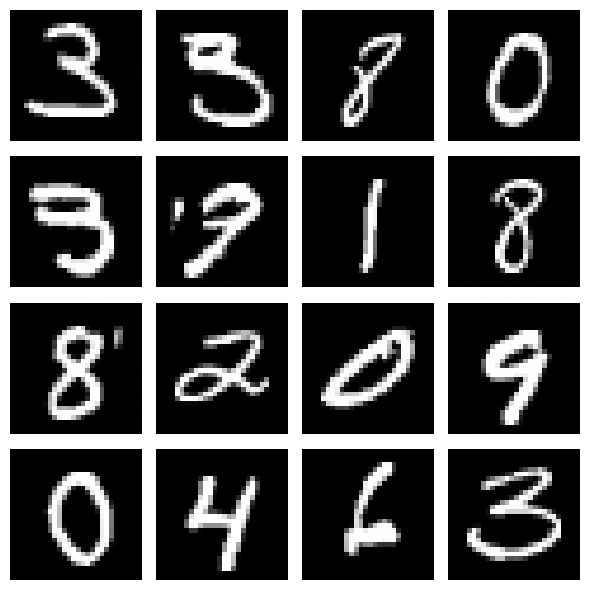

In [24]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

저장된 16장에는 0, 1, 2, 8처럼 읽히는 숫자도 있고, 획이 겹치거나 주변에 작은 점이 남은 숫자도 있다. 앞선 VAE와 DCGAN 출력에도 불완전한 숫자가 있으므로, 이런 현상을 DDPM만의 문제로 볼 수는 없다.

이 결과는 직접 만든 `SimpleUNet`이 아니라 `nathanReitinger/MNIST-diffusion`이 생성했다. 출력된 설정은 `num_train_timesteps=1000`, `beta_schedule='squaredcos_cap_v2'`, `prediction_type='epsilon'`이며, 생성에는 200 step을 사용했다. 앞에서 구현한 선형 noise schedule과도 다르다. VAE·DCGAN과 모델 구조, 학습 조건, 샘플링 방식이 달라 같은 조건의 성능 비교는 아니다.

DDPM은 무작위 잡음에서 시작해 예측한 잡음을 여러 단계에 걸쳐 제거하므로, 노이즈 예측이 부정확하면 획이 어긋난 채 남을 수 있다. 모델의 학습 상태와 추론 단계 수가 영향을 줄 수 있지만, 현재 출력에는 학습 기록이나 step별 비교가 없어 어느 쪽이 원인인지는 확인할 수 없다. 숫자 종류를 지정하지 않는 점은 VAE·DCGAN도 같으므로, 무조건부 생성만으로 이번 차이를 설명할 수는 없다.


## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.

앞선 실습 사진을 보고 하는 것이 아닌 이론적으로 비교해주시면 됩니다.아무래도 실습이다보니 이 결과로 비교하는 것은 이론적으로 틀릴 수도 있어서...

| 모델 | 학습 안정성 | 생성 품질 | 추론·샘플링 속도 |
| --- | --- | --- | --- |
| VAE | 하나의 ELBO 목적함수를 최적화하므로 적대적 학습보다 대체로 안정적이다. 복원 항과 KL 항의 균형은 필요하다. | 분포를 확률적으로 표현하지만 단순한 decoder와 픽셀별 복원 손실에서는 경계가 흐릿해질 수 있다. | 잠재값을 뽑은 뒤 decoder를 한 번 통과하므로 빠르다. |
| GAN | 두 네트워크의 균형에 민감하고 진동, mode collapse가 생길 수 있다. | 선명한 이미지를 잘 생성하지만 일부 모드를 놓칠 수 있다. | Generator를 한 번 통과하므로 빠르다. |
| Diffusion | 잡음을 정답으로 삼는 회귀 학습이라 대체로 안정적이다. 다만 학습 계산량은 클 수 있다. | 충분한 모델 용량과 학습량이 있으면 높은 품질과 다양성을 얻는다. | 기본 DDPM은 노이즈 제거를 여러 번 반복하므로 느리다. DDIM 등으로 단계를 줄일 수 있다. |

이는 전형적인 모델 구조의 비교다. 학습 데이터와 계산 예산이 다른 실습 이미지 몇 장만으로 모델 계열의 우열을 확정하지 않는다. [VAE](https://arxiv.org/abs/1312.6114), [GAN](https://arxiv.org/abs/1406.2661), [DDPM](https://arxiv.org/abs/2006.11239), [DDIM](https://arxiv.org/abs/2010.02502)


## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [25]:
!pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [26]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

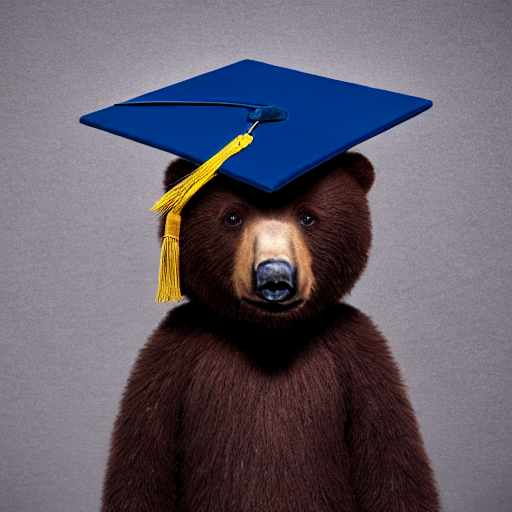

In [27]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=30,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

num_inference_steps는 생성 과정에서 스케줄러가 사용할 노이즈 제거 단계 수다. 여기서는 30으로 설정했다. 학습 epoch나 학습 때의 전체 timestep 수를 바꾸는 값은 아니다.

단계를 늘리면 보통 세부 구조를 다듬을 여유가 생기지만 실행 시간이 길어지고, 어느 수준부터는 품질 개선이 작아진다. 단계를 줄이면 빨라지지만 형태나 질감이 덜 완성될 수 있다. 효과는 스케줄러와 모델에 따라 달라지므로 무조건 많이 설정하는 것이 정답은 아니다.


## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

CFG는 조건 없는 노이즈 예측과 프롬프트 조건의 예측 차이를 증폭한다. 식은 $\hat{\epsilon}=\epsilon_{uncond}+s(\epsilon_{cond}-\epsilon_{uncond})$이며 s가 guidance_scale이다.

s=1.0에서는 조건부 예측을 그대로 사용하므로 추가적인 guidance 증폭이 없다. 프롬프트를 완전히 무시한다는 뜻은 아니다. s=15.0이면 곰, 학사모 같은 조건을 더 강하게 반영하도록 유도하지만 과도한 색 대비나 부자연스러운 형태가 생길 수 있다. 

저장된 비교 이미지는 같은 프롬프트, 30 step, seed=42에서 생성됐다. guidance_scale=1.0인 왼쪽은 실제 곰처럼 보이는 몸통과 촬영 장비가 나오지만, 학사모가 얼굴을 가려 눈과 코가 뚜렷하지 않다. guidance_scale=15.0인 오른쪽은 학사모와 얼굴이 뚜렷하고 배경이 단순하지만, 곰이 봉제인형처럼 표현됐으며 프롬프트에 없던 노란 두루마리도 생겼다.

두 결과 모두 곰과 학사모를 반영했다. 높은 값에서는 이 요소들이 더 뚜렷해졌지만, 실제 곰 사진처럼 자연스러운 결과까지 보장하지는 않았다.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

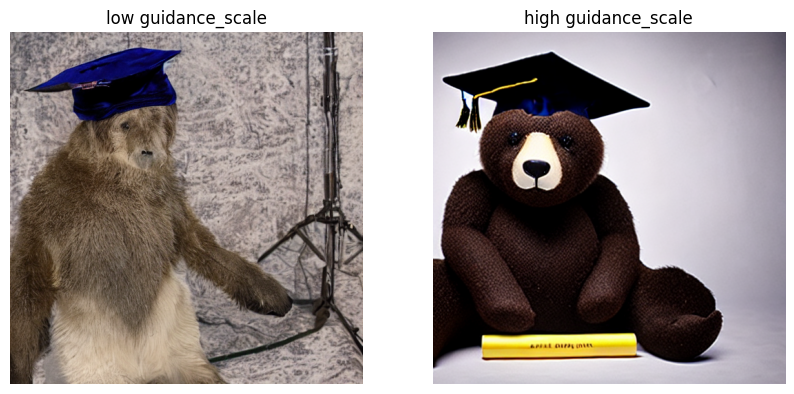

In [28]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=1.0, generator=torch.Generator(device="cpu").manual_seed(42)).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15.0, generator=torch.Generator(device="cpu").manual_seed(42)).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

같은 프롬프트를 사용해 guidance_scale=1.0과 15.0으로 이미지를 각각 생성한다. 두 호출의 num_inference_steps는 30으로 고정한다.

각 호출마다 같은 seed=42로 초기화한 torch.Generator를 전달해 시작 잡음도 맞춘다. 하나의 Generator 객체를 초기화 없이 연속 사용하면 난수 상태가 달라지므로 비교 조건이 달라진다. 반환된 images[0]을 각각 꺼내 두 subplot에 나란히 표시한다. 

### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

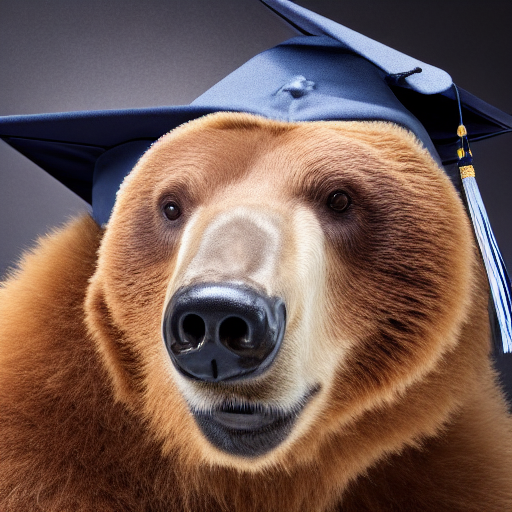

In [29]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

DDPM은 각 단계에서 노이즈를 예측하고, 이를 이용해 더 낮은 노이즈 수준의 이미지를 확률적으로 만든다. DDIM은 같은 노이즈 예측 모델을 사용하되, 현재 이미지에서 원본을 추정한 뒤 선택한 더 낮은 timestep의 이미지로 바로 이동하는 갱신식을 사용한다. 학습 때의 모든 timestep을 거치지 않아도 되므로 모델을 다시 학습하지 않고 단계 수를 줄일 수 있다. eta=0이면 각 단계에서 새 잡음을 추가하지 않아 시작 잡음이 같을 때 역과정이 결정적이다.

DDPM도 이번 Part 3처럼 학습 스케줄 1,000단계보다 적은 200단계로 추론할 수 있다. 적은 step을 쓸 수 있다는 사실만으로 두 방식을 구분하기보다는, 역과정의 갱신식과 잡음을 추가하는 방식을 비교해야 한다. 어느 방식이든 단계를 지나치게 줄이면 품질이 떨어질 수 있다.

저장된 DDIM 20 step 결과에는 학사모를 쓴 곰의 얼굴과 털이 뚜렷하게 보인다. 다만 앞선 Stable Diffusion 30 step 결과와 시작 잡음을 맞추지 않았고 실행 시간도 출력하지 않아, 품질이나 속도가 얼마나 달라졌는지는 이 결과만으로 판단할 수 없다. 교체 전 스케줄러의 종류도 출력되지 않았으므로, 이 실험을 DDPM과 DDIM의 직접 비교라고 부를 근거는 없다.


## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)

Hugging Face 모델을 Python 라이브러리 API로 사용하는 방식을 택했다. `StableDiffusionPipeline.from_pretrained`로 `runwayml/stable-diffusion-v1-5`를 불러오고 CUDA에서 학사모를 쓴 곰 이미지를 생성했다. 이 코드는 모델 가중치를 내려받아 실행 환경의 GPU로 추론한다.

30 step, guidance_scale=7.5의 저장된 결과에는 파란 학사모와 노란 술을 단 곰이 회색 배경 앞에 나온다. 같은 seed로 CFG를 비교한 결과, 1.0에서는 학사모가 얼굴을 가렸고 15.0에서는 학사모와 얼굴이 뚜렷한 곰 인형처럼 표현됐다. 값을 높이면 원하는 단어가 더 뚜렷해져도 사진의 자연스러움까지 좋아지는 것은 아니었다. DDIM으로 바꾼 20 step 결과에서도 학사모와 곰의 형태를 확인했다.

모델을 직접 학습하지 않고 프롬프트와 몇 가지 설정만 바꿔 이미지를 생성할 수 있었다. 다만 설정값이 크다고 항상 더 마음에 드는 그림이 나오는 것은 아니어서, 학사모가 제대로 표현됐는지와 곰의 모습이 자연스러운지를 함께 살펴보는 것이 필요했다. 실행 시간은 저장된 출력에 없어 속도 차이는 비교하지 않았다.



## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 
<br>DDPM을 처음 봐서 그 원리를 설명해주는 부분과 관련 코드 설명해주는 것을 위해서 자세히 사용해서 썼다.</br>

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: 
  없습니다..

- **실제 대화 내역** 붙여넣기:

```
DDPMpipline 관련 코드 작동 원리와 파라미터 알려줘

1. 자주 사용되는 파이프라인 코드의 종류
실무나 연구 코드에서는 목적에 따라 크게 세 가지 종류의 파이프라인이 가장 자주 사용됩니다.

DDPMPipeline (기본형): 가장 기본적인 파이프라인입니다. 텍스트 등의 조건 없이 모델이 학습한 도메인 내에서 무작위로 데이터를 생성(Unconditional Generation)할 때 사용합니다. 정석대로 모든 타임스텝(예: 1000번)을 순회하므로 속도가 느린 편입니다.

DDIMPipeline (속도 개선형): DDPM의 치명적인 단점인 '느린 추론 속도'를 해결한 코드입니다. 스케줄러가 노이즈를 제거하는 방식을 확률적(Markov)에서 확정적(Non-Markov)으로 바꿔, 1000번 돌아야 할 루프를 50번 내외로 건너뛰며 실행해도 품질이 유지되도록 최적화되어 있습니다.

StableDiffusionPipeline (조건부 & 경량화): 고해상도 데이터를 다룰 때 GPU 메모리(VRAM) 한계를 극복하기 위한 파이프라인입니다. 데이터를 픽셀 단위에서 연산하지 않고, VAE(Autoencoder)를 통해 훨씬 작게 압축된 잠재 공간(Latent Space)에서 노이즈 루프를 돌립니다. 텍스트 프롬프트를 조건으로 받는 기능도 포함되어 있습니다.

2. 파이프라인 내부 코드 작동 원리
이러한 파이프라인 코드를 불러와 pipeline() 형태로 실행하면, 내부적으로는 GPU 텐서 연산을 기반으로 한 추론 루프가 돌아갑니다. 아래는 파이프라인 내부에 감춰진 실제 작동 코드를 단순화한 모습입니다.

Python
import torch

# 파이프라인 내부에는 이미 학습이 완료된 모델(U-Net)과 스케줄러가 로드되어 있습니다.
# unet = pipeline.unet
# scheduler = pipeline.scheduler

# [1] 초기 노이즈 텐서 생성
# 생성하고자 하는 데이터 크기(배치, 채널, 높이, 너비)에 맞춰 순수 가우시안 노이즈를 GPU에 올립니다.
latents = torch.randn((1, 3, 256, 256), device="cuda")

# [2] 타임스텝 역순 순회 (예: 1000 -> 999 -> ... -> 1)
for t in scheduler.timesteps:
    
    # [3] 모델(U-Net)의 노이즈 예측
    # 현재 노이즈가 낀 데이터(latents)와 현재 스텝(t)을 U-Net에 입력합니다.
    with torch.no_grad():
        # 모델은 "이 텐서에는 이만큼의 노이즈가 끼어있다"고 계산해 residual_noise로 반환합니다.
        residual_noise = unet(latents, t).sample
        
    # [4] 스케줄러를 통한 디노이징 (핵심)
    # 단순히 텐서끼리 빼는 것이 아니라, 스케줄러의 수식(step)을 통과시켜 
    # 현재 노이즈를 덜어낸 이전 타임스텝(t-1)의 더 선명한 상태를 계산합니다.
    latents = scheduler.step(residual_noise, t, latents).prev_sample

# 루프가 끝나면 latents에는 노이즈가 완전히 제거된 최종 결과물이 담깁니다.
코드 작동 시 주의 깊게 봐야 할 포인트
반복문(Loop) 구조: 한 번의 Forward Pass로 결과를 내는 다른 딥러닝 모델(ResNet 등)과 달리, Diffusion 파이프라인은 동일한 U-Net 모델을 수십~수백 번 반복 호출해야 하므로 이 루프 구간에서 병목(Bottleneck)이 발생합니다.

타임스텝 임베딩(t): U-Net에 latents와 함께 t를 전달하는 것이 필수적입니다. 모델이 전체 단계 중 지금이 초반(형태를 잡는 단계)인지 후반(디테일을 살리는 단계)인지 파악해야 알맞은 노이즈를 예측할 수 있기 때문입니다.

```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? 
<br>CFG 15.0에서 학사모는 뚜렷했지만 곰이 인형처럼 보여, 프롬프트 반영 정도와 사진의 자연스러움을 함께 보고 품질을 판단했다.</br>



수고하셨습니다 ☺️